## 0 · Install Dependencies


In [1]:
!pip install torch scikit-learn matplotlib seaborn scipy -q


## 1 · Imports


In [2]:
# Standard library:
import os
import random
import copy
from itertools import product
import json
import re

# Scientific computing:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import math

# Visualization:
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# PyTorch:
!pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset

# Torchvision:
!pip install torchvision
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as transforms

# Model summary:
!pip install torchinfo
from torchinfo import summary

# Optuna:
!pip install optuna
import optuna

# Progress bar:
from tqdm import tqdm

# OpenCV:
!pip install opencv-python
import cv2

# PIL (Pillow):
from PIL import Image

import re

!pip install nilearn
from nilearn.datasets import fetch_atlas_schaefer_2018
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from collections import defaultdict

## 2 · Device & Reproducibility


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [4]:
# Ensure reproducibility by fixing the random seed.
seed = 34

# Define function to handle reproducibility
def set_seed(seed=seed):
    # Fix seed for Python's built-in random module:
    random.seed(seed)
    
    # Fix seed for NumPy random operations:
    np.random.seed(seed)

    # Fix seed for PyTorch CPU operations:
    torch.manual_seed(seed)

    # Fix seed for GPU operations if CUDA is available
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Force deterministic behavior in CUDA convolution and backend operations:
    torch.backends.cudnn.deterministic = True

    # Disable CuDNN benchmarking to prevent selecting different algorithms per run
    torch.backends.cudnn.benchmark = False

# Ensure reproducibility:
set_seed(seed)

## 3 · Load Data


In [5]:
# Load dataset metadata:
df = pd.read_csv("../../eda/OASIS3_metadata_final.csv")

# Define relative paths of the FC matrices:
NORMCOG_DIR = "../../postprocessing/FC/FC_Maps_Node/NORMCOG"
DEMENTED_DIR = "../../postprocessing/FC/FC_Maps_Node/DEMENTED"

# Initialize empty lists to store the gender and age of the subjects:
genders = []
ages = []

# Helper function to load FC matrices and assign the corresponding class label:
def load_fc(dir_path, label, df):

    # Initialize local containers:
    FC_local = []
    labels_local = []
    ages = []
    genders = []

    # Initialize an empty list to store (subject_id, filename) pairs for sorting:
    files = []

    # Iterate over all files in the given directory:
    for fname in os.listdir(dir_path):
        
        # Proceed only if the filename matches the expected pattern:
        if fname.startswith("sub") and fname.endswith(".mat"):

            # Extract numeric subject ID from filename:
            match = re.search(r'OAS(\d+)', fname)

            # Proceed if a valid subject ID is found:
            if match:
                # Append tuple of (subject_number, filename) for later sorting:
                files.append((int(match.group(1)), fname))

    # Sort files by subject ID to ensure consistent loading order:
    files.sort(key=lambda x: x[0])

    # Iterate over sorted files:
    for _, fname in files:

        # Extract subject ID:
        subject_id = re.search(r'(OAS\d+)', fname).group(1)
        
        # Find matching row in the dataframe:
        row = df[df['Subject_ID'] == subject_id]
        
        # Get Age and Gender values:
        age = row['Age'].iloc[0]
        gender = row['Gender'].iloc[0]

        # Build full file path for current .mat file:
        path = os.path.join(dir_path, fname)

        # Load the .mat file:
        mat = loadmat(path)

        # Save the FC matrix, the corresponding clinical label, the gender and the age:
        FC_local.append(mat['fc_matrix'])
        labels_local.append(label)
        ages.append(age)
        genders.append(gender)

    # Return the FC matrices, labels, ages and genders of the clinical group:
    return FC_local, labels_local, ages, genders

# Load CN class data:
fc1, y1, ages1, genders1 = load_fc(NORMCOG_DIR, "CN", df)

# Load AD class data:
fc2, y2, ages2, genders2 = load_fc(DEMENTED_DIR, "AD", df)

# Join and convert lists to NumPy arrays:
FC = np.array(fc1 + fc2)
labels = np.array(y1 + y2)
ages = np.array(ages1 + ages2)
genders = np.array(genders1 + genders2)

# Build a dataset where each item contains a FC matrix and the corresponding label:
dataset = [{"FC": FC[i], "Label": labels[i], "Age": ages[i], "Gender": genders[i]} for i in range(len(FC))]

# Group the dataset by category:
dataset_grouped = {}

# Iterate through the samples in the dataset:
for sample in dataset:
    # Take the category of the current sample:
    cat = sample["Label"]
    dataset_grouped.setdefault(cat, []).append(sample["FC"])

# Dataset summary:
print("Total FC matrices:", len(dataset))
print("Number of rows of each FC matrix:", FC.shape[1])
print("Number of columns of each FC matrix:", FC.shape[2])
print()

# Categories present:
print("Labels:", ", ".join(str(k) for k in dataset_grouped.keys()))
print()

# Entries per label:
print("Number of entries per label:")
for cat in dataset_grouped:
    print(f"{cat}: {len(dataset_grouped[cat])} entries")
print()

Total FC matrices: 1086
Number of rows of each FC matrix: 300
Number of columns of each FC matrix: 300

Labels: CN, AD

Number of entries per label:
CN: 686 entries
AD: 400 entries



In [6]:
# Build dataset dataframe:
df = pd.DataFrame({"label": labels, "FC": list(FC), "Age": ages, "Gender": genders})

# Define desired label order:
class_order = ["CN", "AD"]

# Enforce categorical dtype with explicit order
df["label"] = pd.Categorical(df["label"], categories=class_order, ordered=True)

# Encode labels:
y = df["label"].cat.codes.values

# Show mapping:
print("Label mapping:")
for i, c in enumerate(class_order):
    print(f"{c}: {i}")

Label mapping:
CN: 0
AD: 1


## 4 · Preprocessing


In [7]:
# Handle NaN values #

# Convert the FC matrix data type to float32:
X = np.array(FC).astype(np.float32)

# Count the total amount of NaN values:
nan_count = np.isnan(X).sum()
print("Total NaN values:", nan_count)

# If at least a missing NaN value is found:
if nan_count != 0:
    # Replace NaNs with 0:
    X = np.nan_to_num(X, nan=0.0)
    
    # Count the total amount of NaN values:
    nan_count = np.isnan(X).sum()
    print("Total NaN values:", nan_count)

Total NaN values: 0


In [8]:
# Apply Fisher z-transformation to the FC matrices individually #

# Avoid values exactly equal to -1 or 1:
X_clipped = np.clip(X, -0.999999, 0.999999)

# Apply Fisher z-transformation:
X_fisher = np.arctanh(X_clipped)

print("Fisher-transformation performed.")

Fisher-transformation performed.


In [9]:
# Add channel dimension for CNN input compatibility #
# CNN input shape: [Number of FC matrices (N), Number of Channels (C), FC Matrix Height (H), FC Matrix Width (W) #
X = np.expand_dims(X_fisher, axis=1)

# Print new input dataset shape:
N, C, H, W = X.shape

print(f"CNN input shape: {X.shape}")
print(f"Number of FC Matrices (N): {N}")
print(f"Number of Channels (C): {C}")
print(f"FC Matrix Height (H): {H} ")
print(f"FC Matrix Width (W): {W} ")

CNN input shape: (1086, 1, 300, 300)
Number of FC Matrices (N): 1086
Number of Channels (C): 1
FC Matrix Height (H): 300 
FC Matrix Width (W): 300 


## 5 · Reproduce Exact Same Train / Val / Test Split

**Critical:** use the same seed, stratification variable and split proportions as during training to guarantee the test set is identical.


In [10]:
# Create a binary indicator: 1 if Age is 75 or older, otherwise 0
df["age_bin"] = (df["Age"] >= 75).astype(int)

# Combine label, age group and gender into a single stratification variable:
stratify_col = (y.astype(str) + "_" + df["age_bin"].astype(str) + "_" + df["Gender"].astype(str))

# Print the stratum distribution:
print("Stratum distribution:\n", stratify_col.value_counts())

Stratum distribution:
 0_0_2    343
0_0_1    235
1_1_1    119
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64


In [11]:
# Perform Train / Validation / Test Data Splits #

# First split:
# 80%: Train + Validation.
# 20%: Test.

# Perform the (Train + Validation) and Test data split considering both data stratification (to preserve class proportion across splits) and random seed reproducibility:
X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(X, y, df.index, test_size=0.2, stratify=stratify_col, random_state=seed)

# Get the dataframe rows of the trainval split:
df_trainval = df.loc[idx_trainval]

# Build stratification only considering the trainval split:
stratify_trainval = (y_trainval.astype(str) + "_" + df_trainval["age_bin"].astype(str).values + "_" + df_trainval["Gender"].astype(str).values)

# Second split:
# From the remaining 80%:
# 75%: Train.
# 25%: Validation.

# Perform the Train and Validation data split considering both data stratification and random seed reproducibility:
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(X_trainval, y_trainval, idx_trainval, test_size=0.25, stratify=stratify_trainval, random_state=seed)

# Final proportions:
# 60% Train / 20% Validation / 20% Test

# Print final data split input shapes:
print("=== INPUT SHAPES ===")
print("Train input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)
print("Test input shape:", X_test.shape)
print()

# Print final data split label shapes:
print("=== LABEL SHAPES ===")
print("Train label shape:", y_train.shape[0])
print("Validation label shape:", y_val.shape[0])
print("Test label shape:", y_test.shape[0])

=== INPUT SHAPES ===
Train input shape: (651, 1, 300, 300)
Validation input shape: (217, 1, 300, 300)
Test input shape: (218, 1, 300, 300)

=== LABEL SHAPES ===
Train label shape: 651
Validation label shape: 217
Test label shape: 218


## 6 · Convert to Tensors


In [12]:
# Convert input data train, validation and test data splits into tensors:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Convert label train, validation and test splits into tensors:
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

## 7 · BrainNetCNN Architecture


In [13]:
# E2E (Edge-to-Edge) Convolutional Layer:
class E2ELayer(nn.Module):
    """
    Edge-to-Edge convolutional layer.

    Captures relationships between pairs of edges (i,j) and (j,k) that share
    a common node j. Applied both row-wise and column-wise to exploit the
    symmetric structure of FC matrices.

    Input shape:  (batch, in_channels, N, N)
    Output shape: (batch, out_channels, N, N)
    """

    def __init__(self, in_channels, out_channels, n_rois):
        """
        Args:
            in_channels  (int): Number of input feature maps (channels), 1 in the case of FC matrices.
            out_channels (int): Number of output feature maps (channels).
            n_rois       (int): Number of brain regions (matrix dimension N), 300 in out case.
        """

        # Call the parent nn.Module constructor:
        super().__init__()

        # Store the number of ROIs or nodes (300 in our case) for use in forward pass:
        self.n_rois = n_rois

        # Row-wise 1D convolution: scans along each row of the matrix.
        #
        # kernel_size=(1, N) means that when slid across the input (B,C,N,N) it aggregates 
        # all columns in a single row, so each row is entirely read. 
        #
        # Each output scalar at position (i, :) is a weighted sum of all edges in row i, 
        # this is, all connections from node i to every other node. Output shape: (B, out_ch, N, 1)
        #
        # This captures how a given node i connects to all other nodes j.
        self.conv_row = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(1, n_rois), padding=0)

        # Column-wise 1D convolution: scans along each column of the matrix.
        #
        # kernel_size=(N, 1) means that when slid across the input (B,C,N,N) it aggregates 
        # all rows in a single column, so each column is entirely read.
        #
        # Each output scalar at position (:, j) is a weighted sum of all edges in column j, 
        # this is, all connections from node j to every other node. Output shape: (B, out_ch, N, 1)
        #
        # This captures how all nodes i connect to a given node j.
        self.conv_col = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(n_rois, 1), padding=0)

    def forward(self, x):
        """
        Forward pass: apply row-wise and column-wise convolutions and sum them.

        Args:
            x (Tensor): Input of shape (batch, in_channels, N, N).

        Returns:
            Tensor: Output of shape (batch, out_channels, N, N).
        """

        # Apply row-wise convolution:
        # Output shape after conv_row: (batch, out_channels, N, 1)
        # Broadcast expand back to (batch, out_channels, N, N) by repeating along dim=3.
        row_out = self.conv_row(x).expand(-1, -1, self.n_rois, self.n_rois)

        # Apply column-wise convolution:
        # Output shape after conv_col: (batch, out_channels, 1, N)
        # Broadcast expand back to (batch, out_channels, N, N) by repeating along dim=2.
        col_out = self.conv_col(x).expand(-1, -1, self.n_rois, self.n_rois)

        # Sum row and column outputs to produce E2E feature maps:
        # The output at position (i,j) encodes "all edges touching node i, plus all edges touching node j".
        return row_out + col_out


# E2N (Edge-to-Node) Convolutional Layer:
class E2NLayer(nn.Module):
    """
    Edge-to-Node convolutional layer.

    Aggregates all edge features incident to each node, producing one feature
    vector per node. Reduces the N×N matrix to an N×1 (or 1×N) representation.

    Input shape:  (batch, in_channels, N, N)
    Output shape: (batch, out_channels, N, 1)
    """

    def __init__(self, in_channels, out_channels, n_rois):
        """
        Args:
            in_channels  (int): Number of input feature maps.
            out_channels (int): Number of output feature maps.
            n_rois       (int): Number of brain regions (N).
        """

        # Call the parent nn.Module constructor:
        super().__init__()

        # Full-width convolution: aggregates all N columns for each row to obtain a single scalar.
        # Output width becomes 1, retaining N rows (one per node).
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(1, n_rois), padding=0)

    def forward(self, x):
        """
        Forward pass.

        Args:
            x (Tensor): Input of shape (batch, in_channels, N, N).

        Returns:
            Tensor: Output of shape (batch, out_channels, N, 1).
        """

        # Apply convolution to collapse each row into a single node embedding:
        return self.conv(x)


# N2G (Node-to-Graph) Convolutional Layer:
class N2GLayer(nn.Module):
    """
    Node-to-Graph convolutional layer (Global Pooling).

    Aggregates all node-level features into a single graph-level representation.
    Reduces the (N, 1) node feature map to a (1, 1) scalar per channel.

    Input shape:  (batch, in_channels, N, 1)
    Output shape: (batch, out_channels, 1, 1)
    """

    def __init__(self, in_channels, out_channels, n_rois):
        """
        Args:
            in_channels  (int): Number of input feature maps.
            out_channels (int): Number of output feature maps.
            n_rois       (int): Number of brain regions (N).
        """

        # Call the parent nn.Module constructor:
        super().__init__()

        # Full-height convolution: aggregates the entire column of N node embeddings and produces a single scalar.
        # Output height becomes 1 (whole-brain graph-level summary).
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(n_rois, 1), padding=0)

    def forward(self, x):
        """
        Forward pass.

        Args:
            x (Tensor): Input of shape (batch, in_channels, N, 1).

        Returns:
            Tensor: Output of shape (batch, out_channels, 1, 1).
        """

        # Apply convolution to collapse all nodes into a graph-level feature:
        return self.conv(x)



# Full BrainNetCNN Model:
class BrainNetCNN(nn.Module):
    """
    BrainNetCNN: Convolutional Neural Network for Brain Connectivity Matrices.

    Architecture:
        Input (N×N FC matrix)
            ↓
        E2E Layer → BN → LeakyReLU → Dropout
            ↓
        E2N Layer → BN → LeakyReLU → Dropout
            ↓
        N2G Layer → BN → LeakyReLU → Dropout
            ↓
        Flatten
            ↓
        FC Layer 1 → BN → LeakyReLU → Dropout
            ↓
        FC Layer 2 → BN → LeakyReLU → Dropout
            ↓
        Output Layer (num_classes logits)

    Designed for symmetric N×N functional connectivity matrices.
    """

    def __init__(
        self,
        n_rois,                  # Number of brain ROIs (matrix dimension N×N).
        num_classes=2,           # Number of output classes (CN vs AD).
        e2e_channels=32,         # Number of output channels from E2E layer.
        e2n_channels=64,         # Number of output channels from E2N layer.
        n2g_channels=128,        # Number of output channels from N2G layer.
        fc_neurons=[256, 128],   # Neurons in each fully connected dense layer.
        dropout=0.5,             # Dropout probability.
        activation="leakyrelu"   # Activation function.
    ):
        """
        Args:
            n_rois       (int):   Dimension of the square FC matrix (N).
            num_classes  (int):   Number of output classes.
            e2e_channels (int):   Filters in the E2E layer.
            e2n_channels (int):   Filters in the E2N layer.
            n2g_channels (int):   Filters in the N2G layer.
            fc_neurons   (list):  List of neuron counts for each FC dense layer.
            dropout      (float): Dropout rate for regularization.
            activation   (str):   Activation function name.
        """

        # Call the parent nn.Module constructor:
        super().__init__()

        # Store n_rois for reference:
        self.n_rois = n_rois

        # Map string names to PyTorch activation classes:
        activation_dict = {
            "relu":      nn.ReLU,
            "leakyrelu": nn.LeakyReLU,
            "elu":       nn.ELU,
            "tanh":      nn.Tanh,
            "sigmoid":   nn.Sigmoid
        }

        # Retrieve the activation class (default to LeakyReLU if not found):
        act_fn = activation_dict.get(activation.lower(), nn.LeakyReLU)

        # Diagonal masking parameter #

        # Register a binary mask that zeros out the diagonal of the FC matrix.
        # The diagonal (self-correlations = 1.0) carries no connectivity info.
        # Using register_buffer ensures it moves with the model to GPU/CPU.
        mask = torch.ones(n_rois, n_rois) # Start with all ones
        mask.fill_diagonal_(0) # Zero out the diagonal entries
        self.register_buffer("diag_mask", mask) # Register as non-trainable buffer

        # E2E Layer Block #

        # E2E layer: captures shared-node edge relationships across the matrix.
        # Input channels = 1 (single FC matrix treated as a 1-channel image).
        self.e2e = E2ELayer(in_channels=1, out_channels=e2e_channels, n_rois=n_rois)

        # Batch normalization after E2E to stabilize training:
        self.e2e_bn = nn.BatchNorm2d(e2e_channels)

        # Activation after E2E:
        self.e2e_act = act_fn()

        # Dropout after E2E for regularization:
        self.e2e_drop = nn.Dropout(dropout)

        # E2N Layer Block #

        # E2N layer: aggregates all edge features incident to each node.
        # Input channels = e2e_channels (output from previous E2E layer, 32 by default).
        self.e2n = E2NLayer(in_channels=e2e_channels, out_channels=e2n_channels, n_rois=n_rois)

        # Batch normalization after E2N:
        self.e2n_bn = nn.BatchNorm2d(e2n_channels)

        # Activation after E2N:
        self.e2n_act = act_fn()

        # Dropout after E2N:
        self.e2n_drop = nn.Dropout(dropout)

        # N2G Layer Block #

        # N2G layer: collapses all node features into a single graph embedding.
        # Input channels = e2n_channels (output from E2N layer, 64 by default).
        self.n2g = N2GLayer(in_channels=e2n_channels, out_channels=n2g_channels, n_rois=n_rois)

        # Batch normalization after N2G:
        self.n2g_bn = nn.BatchNorm2d(n2g_channels)

        # Activation after N2G:
        self.n2g_act = act_fn()

        # Dropout after N2G:
        self.n2g_drop = nn.Dropout(dropout)

        # Fully Connected Classifier #

        # After N2G, output shape is (batch, n2g_channels, 1, 1).
        # Flattened size = n2g_channels (one scalar per channel, 128 channels by default):
        in_features = n2g_channels

        # Initialize an empty list to hold FC layer modules:
        fc_blocks = []

        # Build each fully connected dense layer dynamically:
        for neurons in fc_neurons:

            # Linear transformation:
            fc_blocks.append(nn.Linear(in_features, neurons))

            # Batch normalization for FC layer:
            fc_blocks.append(nn.BatchNorm1d(neurons))

            # Activation:
            fc_blocks.append(act_fn())

            # Dropout:
            fc_blocks.append(nn.Dropout(dropout))

            # Update input size for the next layer:
            in_features = neurons

        # Final output layer: maps to num_classes logits (no activation here,
        # since CrossEntropyLoss expects raw logits):
        fc_blocks.append(nn.Linear(in_features, num_classes))

        # Combine all FC blocks into a sequential module:
        self.classifier = nn.Sequential(*fc_blocks)

    def forward(self, x):
        """
        Forward pass through BrainNetCNN.

        Args:
            x (Tensor): Input FC matrix of shape (batch, 1, N, N).

        Returns:
            Tensor: Logits of shape (batch, num_classes).
        """

        # Step 1: Zero out the diagonal (self-correlations are uninformative) #
        # Multiply input by the diagonal mask (broadcast over batch and channels):
        x = x * self.diag_mask

        # Step 2: E2E Block #
        x = self.e2e(x)       # Edge-to-edge convolution: (B, 1, N, N) → (B, e2e_ch, N, N)
        x = self.e2e_bn(x)    # Batch normalization
        x = self.e2e_act(x)   # Activation
        x = self.e2e_drop(x)  # Dropout

        # Step 3: E2N Block #
        x = self.e2n(x)       # Edge-to-node convolution: (B, e2e_ch, N, N) → (B, e2n_ch, N, 1)
        x = self.e2n_bn(x)    # Batch normalization
        x = self.e2n_act(x)   # Activation
        x = self.e2n_drop(x)  # Dropout

        # Step 4: N2G Block #
        x = self.n2g(x)       # Node-to-graph convolution: (B, e2n_ch, N, 1) → (B, n2g_ch, 1, 1)
        x = self.n2g_bn(x)    # Batch normalization
        x = self.n2g_act(x)   # Activation
        x = self.n2g_drop(x)  # Dropout

        # Step 5: Flatten #
        # Flatten from (batch, n2g_channels, 1, 1) → (batch, n2g_channels):
        x = x.view(x.size(0), -1)

        # Step 6: Fully Connected Classifier #
        # Pass through FC layers to produce final class logits:
        x = self.classifier(x)

        # Return raw logits (CrossEntropyLoss applies softmax internally):
        return x

## 8 · Load Trained Model

Instantiate BrainNetCNN with the best hyperparameters found by Optuna and load the saved weights.
Adjust `best_config` below if your best params differ.


In [14]:
import json

# Load best configuration saved during training:
with open("best_config.json", "r") as f:
    best_config = json.load(f)

print("Best config:", best_config)

n_rois = best_config["n_rois"]

# Instantiate BrainNetCNN with the best architecture:
best_model = BrainNetCNN(
    n_rois      = best_config["n_rois"],
    num_classes = best_config["num_classes"],
    e2e_channels= best_config["e2e_channels"],
    e2n_channels= best_config["e2n_channels"],
    n2g_channels= best_config["n2g_channels"],
    fc_neurons  = best_config["fc_neurons"],
    dropout     = best_config["dropout"],
    activation  = best_config["activation"],
).to(device)

# Load trained weights:
best_model.load_state_dict(
    torch.load("best_model_BrainNetCNN.pth", map_location=device)
)
best_model.eval()
print("Model loaded successfully.")

total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Best config: {'e2e_channels': 16, 'e2n_channels': 64, 'n2g_channels': 256, 'fc_neurons': [512, 64], 'dropout': 0.20070643364086163, 'batch_size': 16, 'epochs': 100, 'lr': 0.001702604793338764, 'activation': 'leakyrelu', 'n_rois': 300, 'num_classes': 2}
Model loaded successfully.
Trainable parameters: 5,398,722


## 9 · Test Evaluation Function


In [15]:
# Define a function for model testing:
def test_model(model, test_loader, device, plot=True, save=False):
    ### TESTING PHASE ###
    
    # Set model to evaluation mode:
    model.eval()
        
    # Initialize empty lists to store model predictions and true labels for evaluation:
    preds = []
    trues = []

    # Initialize an empty list to store probabilities for the ROC curve:
    probs = []
        
    # Disable gradient computation:
    with torch.no_grad():
        
        # Iterate over mini-batches from the testing DataLoader:
        for ev_inputs, ev_labels in test_loader:
        
            # Move testing input data and labels to the selected device:
            ev_inputs = ev_inputs.to(device)
        
            # Perform forward pass to compute model predictions (no gradient tracking):
            ev_outputs = model(ev_inputs)

            # Convert logits to probabilities:
            ev_probabilities = F.softmax(ev_outputs, dim=1)
        
            # Get predicted class labels:
            _, ev_predicted = torch.max(ev_outputs, 1)
        
            # Store predictions:
            preds.extend(ev_predicted.cpu().numpy())
        
            # Store true labels:
            trues.extend(ev_labels.numpy())

            # Store probabilities:
            probs.extend(ev_probabilities.cpu().numpy())
            

    # Convert to numpy arrays:
    trues = np.array(trues)
    preds = np.array(preds)
    probs = np.array(probs)
    
    # Compute overall accuracy:
    acc = accuracy_score(trues, preds)

    # Compute macro and weighted precision:
    precision_macro = precision_score(trues, preds, average='macro')
    precision_weighted = precision_score(trues, preds, average='weighted')

    # Compute macro and weighted recall:
    recall_macro = recall_score(trues, preds, average='macro')   
    recall_weighted = recall_score(trues, preds, average='weighted')

    # Compute macro and weighted F1 scores:
    f1_macro = f1_score(trues, preds, average='macro')
    f1_weighted = f1_score(trues, preds, average='weighted')

    # Print evaluation metrics:
    print("\n===== TEST METRICS =====")
    print(f"Accuracy: {acc:.4f}")

    print(f"\nMacro Precision: {precision_macro:.4f}")
    print(f"Weighted Precision: {precision_weighted:.4f}")

    print(f"\nMacro Recall: {recall_macro:.4f}")
    print(f"Weighted Recall: {recall_weighted:.4f}")

    print(f"\nMacro F1-score: {f1_macro:.4f}")
    print(f"Weighted F1-score: {f1_weighted:.4f}")

    # Define label mapping:
    labels = ["Normal", "Demented"]

    # Print classification report:
    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(trues, preds, target_names=labels, digits=4))

    # Store classification report:
    report = classification_report(trues, preds, target_names=labels, digits=4)

    # Save metrics if enabled
    if save:

        # Create output folder:
        os.makedirs("Results", exist_ok=True)

        # Create metric dictionary:
        metrics_dict = {
            "accuracy": acc,
            "precision_macro": precision_macro,
            "precision_weighted": precision_weighted,
            "recall_macro": recall_macro,
            "recall_weighted": recall_weighted,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "classification_report": report
        }

        # Save metrics:
        with open(os.path.join("Results", "2D_CNN_best_test_metrics.json"), "w") as f:
            json.dump(metrics_dict, f, indent=4)
    
    # Helper function to plot confusion matrix:
    def plot_confusion_matrix(trues, preds, labels, title="Confusion Matrix"):
        
        # Generate the confusion matrix using true and predicted labels:
        cm = confusion_matrix(trues, preds, labels=[0,1])
        
        # Convert confusion matrix to percentage:
        cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
        
        # Create a new figure:
        plt.figure(figsize=(6, 5))
        
        # Display the confusion matrix as a heatmap:
        sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, linecolor="black", xticklabels=labels, yticklabels=labels)
        
        # Add x- and y-axis labels:
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        
        # Add a title to the graph:
        plt.title(title)

        # Save figure if enabled:
        if save:
            # Create output folder:
            os.makedirs("Figures/Best_Model", exist_ok=True)
            
            # Save figure:
            # plt.savefig(os.path.join("Figures/Best_Model", "2D_CNN_best_confusion_matrix.png"), dpi=300, bbox_inches="tight")
        
        # Display the final plot:
        plt.show()

    # Helper function to plot the ROC curve:
    def plot_roc(trues, probs, labels, title=r"$\mathbf{ROC}$ Curve"):

        # Take probability of positive class (class 1)
        y_score = probs[:, 1]

        # Create a new figure:
        plt.figure(figsize=(8, 6))

        # Compute False Positive Rate (FPR), True Positive Rate (TPR) and threshold values:
        fpr, tpr, _ = roc_curve(trues, y_score)

        # Compute Area Under the Curve (AUC):
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve:
        plt.plot(fpr, tpr, color='red')

        # Plot reference random classifier line:
        plt.plot([0, 1], [0, 1], 'k--')

        # Add x- and y-axis labels:
        plt.xlabel(r"False Positive Rate ($\mathbf{FPR}$)", fontsize=12)
        plt.ylabel(r"True Positive Rate ($\mathbf{TPR}$)", fontsize=12)

        # Add a title to the graph:
        plt.title(title, fontsize=20)

        # Display legend in the lower-right corner:
        plt.legend(loc="lower right")

        # Add grid for better visualization:
        plt.grid(True)

        # Save figure if enabled:
        if save:
            # Create output folder:
            os.makedirs("Figures/Best_Model", exist_ok=True)
            
            # Save figure:
            plt.savefig(os.path.join("Figures/Best_Model", "2D_CNN_best_ROC.png"), dpi=300, bbox_inches="tight")

        # Display the final plot:
        plt.show()
    
    # Show confusion matrix and ROC curve plots only if enabled:
    if plot:
        # Call the helper function to plot the confusion matrix:
        plot_confusion_matrix(trues, preds, labels)

        # Call the helper function to plot the ROC curve:
        plot_roc(trues, probs, labels)

    # Return metrics:
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

## 10 · Full Test Set Evaluation



===== TEST METRICS =====
Accuracy: 0.6835

Macro Precision: 0.6660
Weighted Precision: 0.6941

Macro Recall: 0.6738
Weighted Recall: 0.6835

Macro F1-score: 0.6681
Weighted F1-score: 0.6871

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.7717    0.7101    0.7396       138
    Demented     0.5604    0.6375    0.5965        80

    accuracy                         0.6835       218
   macro avg     0.6660    0.6738    0.6681       218
weighted avg     0.6941    0.6835    0.6871       218



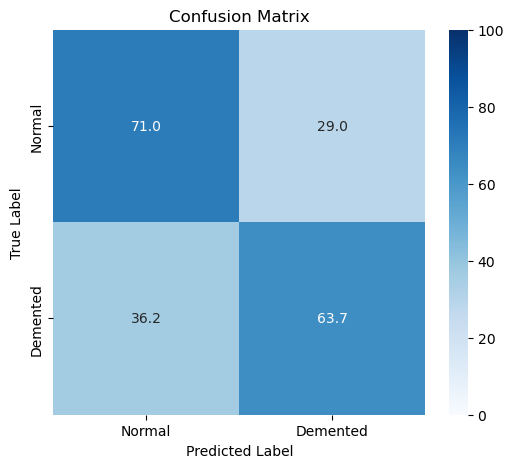

/tmp/ipykernel_80450/1828281627.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


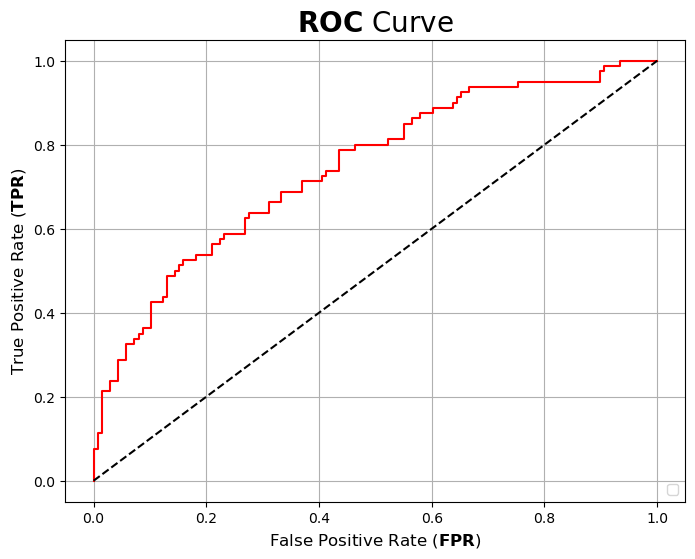

In [16]:
best_batch_size = best_config["batch_size"]

# Create test dataset and dataloader:
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)
test_loader   = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# Evaluate on the full test set:
test_metrics = test_model(best_model, test_loader, device, plot=True, save=True)


## 11 · Young Subject Subgroup Analysis

Evaluate model performance on subjects under 75 years old to assess generalisation to younger patients — typically harder to classify due to subtler structural changes.


Young test subset: Age < 75
Number of subjects : 150

Class distribution:
  CN: 116 (77.3%)
  AD: 34 (22.7%)

Age mean : 65.5
Age std  : 6.3
Age range: 46 – 75

===== YOUNG SUBJECT TEST METRICS =====


/tmp/ipykernel_80450/673465945.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  young_X = X_test_tensor[young_mask.values]



===== TEST METRICS =====
Accuracy: 0.7067

Macro Precision: 0.6244
Weighted Precision: 0.7493

Macro Recall: 0.6544
Weighted Recall: 0.7067

Macro F1-score: 0.6308
Weighted F1-score: 0.7223

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.8529    0.7500    0.7982       116
    Demented     0.3958    0.5588    0.4634        34

    accuracy                         0.7067       150
   macro avg     0.6244    0.6544    0.6308       150
weighted avg     0.7493    0.7067    0.7223       150



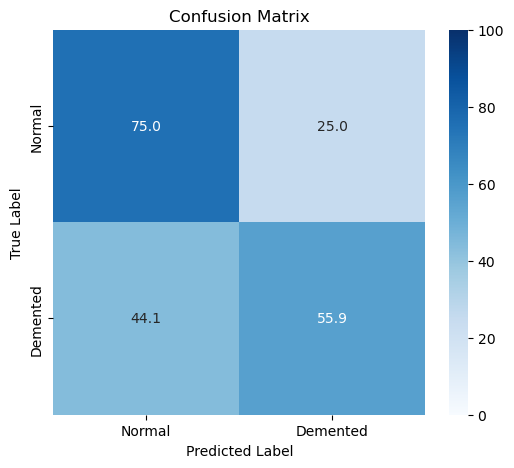

/tmp/ipykernel_80450/1828281627.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


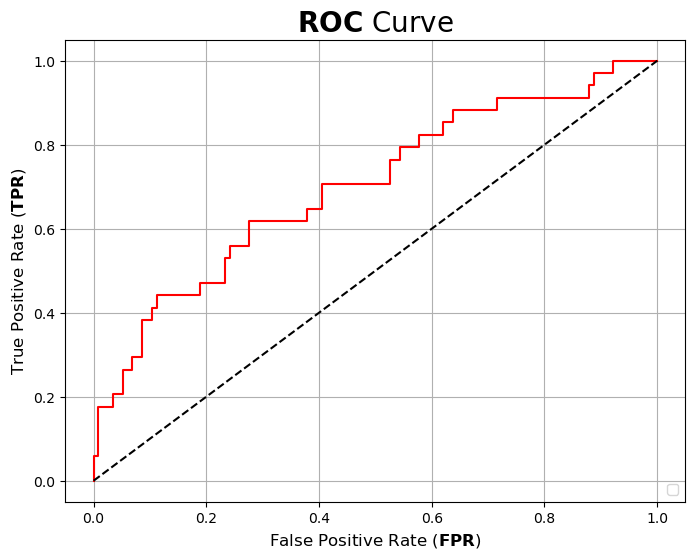

In [17]:
AGE_THRESHOLD = 75

# Recover test indices tracked during the split:
df_test = df.loc[idx_test].reset_index(drop=False)

# Boolean mask for young subjects within the test set:
young_mask = df_test["Age"] < AGE_THRESHOLD

print("=" * 50)
print(f"Young test subset: Age < {AGE_THRESHOLD}")
print("=" * 50)
print(f"Number of subjects : {young_mask.sum()}")
print(f"\nClass distribution:")
young_y = y_test[young_mask.values]
for label, name in [(0, "CN"), (1, "AD")]:
    count = (young_y == label).sum()
    print(f"  {name}: {count} ({count/len(young_y)*100:.1f}%)")
age_vals = df_test.loc[young_mask, "Age"]
print(f"\nAge mean : {age_vals.mean():.1f}")
print(f"Age std  : {age_vals.std():.1f}")
print(f"Age range: {age_vals.min():.0f} – {age_vals.max():.0f}")

# Build young test dataloader:
young_X = X_test_tensor[young_mask.values]
young_y_tensor = y_test_tensor[young_mask.values]

young_dataset = TensorDataset(young_X, young_y_tensor)
young_loader  = DataLoader(young_dataset, batch_size=best_batch_size, shuffle=False)

# Evaluate:
print("\n===== YOUNG SUBJECT TEST METRICS =====")
young_metrics = test_model(best_model, young_loader, device, plot=True, save=True)


## GradCam

In [19]:
# Define a helper function to compute a Grad-CAM heatmap for a single input:
def gradcam(model, input_tensor, device, target_class=None):

    # Put model in evaluation mode:
    model.eval()

    # Move input image tensor to the device where the model is:
    input_tensor = input_tensor.to(device)

    # Hook storage: Initialize empty lists to store intermediate values.
    # Forward Hook: Activations list stores the feature maps produced by the target convolutional layer during forward pass.
    # Backward Hook: Gradients list stores the gradient of the target class score with respect to the feature maps during backpropagation. 'How important is each feature map for predicting this class'.
    activations = [] # Forward hook.
    gradients = [] # Backward hook.

    # Find the last Conv2d layer within the models self.features and define it as the target convolutional layer:
    last_conv = None
    for layer in model.features:
        if isinstance(layer, torch.nn.Conv2d):
            last_conv = layer

    # Register forward hook to capture feature maps or activations.
    # This function is called after the forward pass.
    def forward_hook(module, input, output):
        activations.append(output) # Output is the feature map tensor of shape [1, C, H, W].

    # Register backward hook to capture gradients.
    # This function is called after the backpropagation.
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Attach both forward and backward hooks to the selected target convolutional layer:
    fh = last_conv.register_forward_hook(forward_hook)
    bh = last_conv.register_full_backward_hook(backward_hook)

    # Forward pass #
    # Run the model with the input image tensor to get class scores.
    # As execution passes through the last convolutional layer, the forward hooks fires and saves the feature maps into activations.
    output = model(input_tensor)

    # Take the index of the highest logit as the predicted class:
    pred_class = output.argmax(dim=1).item()

    # If no target class is specified, use predicted class:
    if target_class is None:
        target_class = pred_class

    # Backward pass for target class #

    # Clear previous gradients:
    model.zero_grad()

    # Backpropagate the scalar score of the target class all the way to the feature maps.
    # As gradients flow through the last convolutional layer, the backward hook fires and saves them into gradients.
    output[0, target_class].backward()

    # Detach hooks so that they do not keep firing:
    fh.remove()
    bh.remove()

    # Unpacks the tensors saved by the hooks to compute Grad-CAM:
    grads = gradients[0] # Size [1, C, H, W].
    acts = activations[0] # Size [1, C, H, W].

    # Average the gradient tensor over both spatial dimensions (H and W), producing one importance weight scalar per channel.
    # In this case, as FC matrices have a single channel, a single importance weight scalar is computed.
    # Global average pooling of gradients.
    weights = grads.mean(dim=(2, 3), keepdim=True) # shape [1, C, 1, 1].

    # Weighted combination of activation maps using channel importance.
    # This step multiplies each channel's feature maps by its importance weight, and then sums across all C channels.
    # In this case, as FC matrices have a single channel, the previously computed importance weight scalar is multiplied with the feature maps.
    cam = (weights * acts).sum(dim=1, keepdim=True)

    # Apply ReLU activation function to keep only positive values and remove the negatives in the heatmap.
    # As the negative values mean that the specific region supresses the class, we only want to highlight regions that support the class.
    cam = F.relu(cam)

    # As the heatmap has the spatial resolution of the last convolutional layer, bilinear interpolation is applied to resize the heatmap to match the input image size (H, W):
    H, W = input_tensor.shape[2], input_tensor.shape[3]
    cam = F.interpolate(cam, size=(H, W), mode='bilinear', align_corners=False)

    # Convert tensor to numpy array for visualization, by removing the batch and channel dimensions:
    cam = cam.squeeze().detach().cpu().numpy() # shape [H, W]

    # Normalize heatmap to range [0, 1] for consistent visualization
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()

    # Return heatmap and predicted class:
    return cam, pred_class

In [20]:
# Define a helper function to overlay Grad-CAM heatmap on the input 2D matrix:
def plot_gradcam(input_tensor, heatmap, pred_class, title=None, label_names=["CN", "AD"]):

    if title is None:
        title = f"Average Test $\\mathbf{{{label_names[pred_class]}}}$ $\\mathbf{{FC}}$ Matrix"

    # Convert tensor to 2D NumPy array (remove batch/channel dimension)
    img = input_tensor.squeeze().cpu().numpy()

    # Compute image percentiles for visualization:
    p1, p99 = np.percentile(img, [1, 99])

    # Create a figure:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1: Original FC matric input #
    axes[0].imshow(img, cmap='RdYlBu', aspect='auto', vmin=p1, vmax=p99)
    axes[0].set_title(title, fontsize=26, pad=20)
    axes[0].axis('off')  # Hide axis ticks for cleaner visualization

    # Panel 2: Grad-CAM importance heatmap #
    axes[1].imshow(heatmap, cmap='magma', aspect='auto')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=26, pad=20)
    axes[1].axis('off')

    #  Panel 3: Overlay visualization #
    axes[2].imshow(img, cmap='RdYlBu', aspect='auto')
    axes[2].imshow(heatmap, cmap='magma', alpha=0.3, aspect='auto')

    # Add title with predicted class label:
    axes[2].set_title(f"Overlay", fontsize=26, pad=20)
    axes[2].axis('off')

    # Adjust spacing between subplots to avoid overlap:
    plt.tight_layout()

    # Display the figure:
    plt.show()

In [21]:
# Define a helper fucntion to visualize individual misclassified sample heatmaps:
def plot_misclassified(misclassified_list, true_class_name, pred_class_name):
    # Define the number of misclassified samples:
    n = len(misclassified_list)
    if n == 0:
        print(f"No misclassified {true_class_name} samples found.")
        return

    # Print summary information:
    print(f"\n{'─'*60}")
    print(f"  {true_class_name} → {pred_class_name} misclassifications: {n} sample(s)")
    print(f"{'─'*60}\n")

    # Iterate through the misclassified samples:
    for idx, entry in enumerate(misclassified_list):
        # Print a per-sample header in the console to identify each plot:
        print(f"Sample {idx + 1}/{n} | True: {true_class_name} → Predicted: {pred_class_name}")

        # Plot the heatmap of the current misclassified sample
        plot_gradcam(input_tensor = entry["input"], heatmap = entry["heatmap"], pred_class = entry["pred"])

In [24]:
model = best_model

In [26]:
# Initialize empty lists to store CN and AD heatmaps of the correctly predicted samples:
cn_heatmaps = [] # True CN (class 0) – correct predictions
ad_heatmaps = [] # True AD (class 1) – correct predictions

# Initialize empty lists to store CN and AD heatmaps of the misclassified samples:
cn_misclassified = [] # True CN, predicted AD
ad_misclassified = [] # True AD, predicted CN

# Set the model into evaluation mode:
model.eval()

# Iterate throught the input FC matrices and corresponding labels in the test loader of the optimized model:
for inputs, labels in test_loader:
    # Loop over each sample in the current batch:
    for i in range(inputs.size(0)):

        # Extract a single sample and add the batch dimension back: [1, C, H, W]
        input_single = inputs[i].unsqueeze(0)
        
        # Get the ground truth label for this sample:
        label = labels[i].item()
        
        # Compute the Grad-CAM heatmap and the predicted class for this sample:
        heatmap, pred_class = gradcam(model, input_single, device)

        # Only keep correctly classified samples to avoid polluting the average
        # heatmap with noise from misclassified predictions:
        if pred_class == label:
            # If the ground truth label is CN (class 0), store the heatmap in the CN list:
            if label == 0:
                cn_heatmaps.append(heatmap)
            # Otherwise the ground truth label is AD (class 1), store it in the AD list:
            else:
                ad_heatmaps.append(heatmap)

        else:
            entry = {
                "input":   input_single,
                "heatmap": heatmap,
                "true":    label,
                "pred":    pred_class,
            }
            if label == 0:
                cn_misclassified.append(entry)
            else:
                ad_misclassified.append(entry)

# Average across all samples per class:
mean_cn = np.mean(cn_heatmaps, axis=0)
mean_ad = np.mean(ad_heatmaps, axis=0)

# Plot the average heatmaps of the correctly predicted samples of the CN and AD groups:
plot_gradcam(inputs[0].unsqueeze(0), mean_cn, pred_class=0)
plot_gradcam(inputs[0].unsqueeze(0), mean_ad, pred_class=1)

AttributeError: 'BrainNetCNN' object has no attribute 'features'

Grad-CAM summary
Correct CN heatmaps : 98
Correct AD heatmaps : 51
Misclassified CN    : 40
Misclassified AD    : 29


TypeError: Invalid shape (300,) for image data

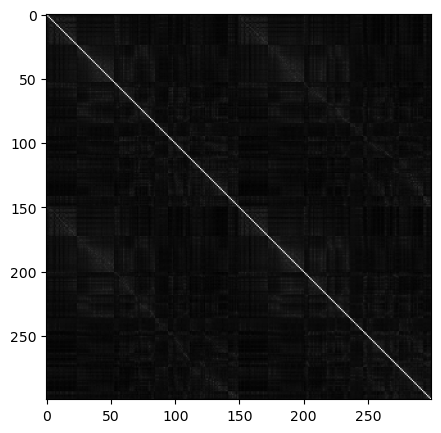

In [28]:
# =========================================================
# Grad-CAM for BrainNetCNN
# =========================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Grad-CAM function
# ---------------------------------------------------------

def gradcam_brainnet(model, input_tensor, device, target_class=None, target_layer=None):
    """
    Compute Grad-CAM for a BrainNetCNN model.

    Parameters
    ----------
    model : torch.nn.Module
        Trained BrainNetCNN model.
    input_tensor : torch.Tensor
        Single input FC matrix with shape [1, C, H, W].
    device : torch.device
        Device used for computation.
    target_class : int or None
        Class for which Grad-CAM is computed. If None, predicted class is used.
    target_layer : torch.nn.Module or None
        Layer used for Grad-CAM. If None, model.e2e.conv_row is used.

    Returns
    -------
    cam : np.ndarray
        Grad-CAM heatmap.
    pred_class : int
        Predicted class.
    """

    model.eval()

    if target_layer is None:
        # Best option for interpretation over the original FC matrix
        target_layer = model.e2e.conv_row

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Register hooks
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad = True

    # Forward pass
    logits = model(input_tensor)
    pred_class = torch.argmax(logits, dim=1).item()

    if target_class is None:
        target_class = pred_class

    # Backward pass for selected class
    model.zero_grad()
    score = logits[:, target_class]
    score.backward()

    # Get activations and gradients
    acts = activations[0].detach()      # [1, C, H, W]
    grads = gradients[0].detach()      # [1, C, H, W]

    # Global average pooling over spatial dimensions
    weights = grads.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

    # Weighted sum of activations
    cam = (weights * acts).sum(dim=1, keepdim=True)  # [1, 1, H, W]

    # ReLU
    cam = torch.relu(cam)

    # Normalize
    cam = cam.squeeze().cpu().numpy()

    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    else:
        cam = np.zeros_like(cam)

    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()

    return cam, pred_class


# ---------------------------------------------------------
# Plot function
# ---------------------------------------------------------

def plot_gradcam(input_tensor, heatmap, pred_class=None, title=None):
    """
    Plot FC matrix with Grad-CAM overlay.
    """

    matrix = input_tensor.squeeze().detach().cpu().numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.45)

    plt.colorbar(label="Grad-CAM intensity")

    if title is not None:
        plt.title(title)
    elif pred_class is not None:
        class_name = "CN" if pred_class == 0 else "AD"
        plt.title(f"Grad-CAM - predicted class: {class_name}")
    else:
        plt.title("Grad-CAM")

    plt.xlabel("Brain region")
    plt.ylabel("Brain region")
    plt.tight_layout()
    plt.show()


# =========================================================
# Compute Grad-CAM heatmaps for test set
# =========================================================

# Correctly classified samples
cn_heatmaps = []   # True CN, predicted CN
ad_heatmaps = []   # True AD, predicted AD

# Input matrices for correctly classified samples
cn_inputs = []
ad_inputs = []

# Misclassified samples
cn_misclassified = []  # True CN, predicted AD
ad_misclassified = []  # True AD, predicted CN

model.eval()

for inputs, labels in test_loader:

    inputs = inputs.to(device)
    labels = labels.to(device)

    for i in range(inputs.size(0)):

        # Single sample: [1, C, H, W]
        input_single = inputs[i].unsqueeze(0)

        # Ground-truth label
        label = labels[i].item()

        # Compute Grad-CAM
        heatmap, pred_class = gradcam_brainnet(
            model=model,
            input_tensor=input_single,
            device=device,
            target_class=None,
            target_layer=model.e2e.conv_row
        )

        # Correctly classified samples
        if pred_class == label:

            if label == 0:
                cn_heatmaps.append(heatmap)
                cn_inputs.append(input_single.detach().cpu())

            else:
                ad_heatmaps.append(heatmap)
                ad_inputs.append(input_single.detach().cpu())

        # Misclassified samples
        else:
            entry = {
                "input": input_single.detach().cpu(),
                "heatmap": heatmap,
                "true": label,
                "pred": pred_class,
            }

            if label == 0:
                cn_misclassified.append(entry)
            else:
                ad_misclassified.append(entry)


print("=" * 60)
print("Grad-CAM summary")
print("=" * 60)
print(f"Correct CN heatmaps : {len(cn_heatmaps)}")
print(f"Correct AD heatmaps : {len(ad_heatmaps)}")
print(f"Misclassified CN    : {len(cn_misclassified)}")
print(f"Misclassified AD    : {len(ad_misclassified)}")


# =========================================================
# Average Grad-CAM heatmaps for correctly classified samples
# =========================================================

if len(cn_heatmaps) > 0:
    mean_cn_heatmap = np.mean(cn_heatmaps, axis=0)
    mean_cn_input = torch.mean(torch.cat(cn_inputs, dim=0), dim=0, keepdim=True)

    plot_gradcam(
        mean_cn_input,
        mean_cn_heatmap,
        pred_class=0,
        title="Mean Grad-CAM - Correctly classified CN"
    )
else:
    print("No correctly classified CN samples found. CN mean Grad-CAM was not computed.")


if len(ad_heatmaps) > 0:
    mean_ad_heatmap = np.mean(ad_heatmaps, axis=0)
    mean_ad_input = torch.mean(torch.cat(ad_inputs, dim=0), dim=0, keepdim=True)

    plot_gradcam(
        mean_ad_input,
        mean_ad_heatmap,
        pred_class=1,
        title="Mean Grad-CAM - Correctly classified AD"
    )
else:
    print("No correctly classified AD samples found. AD mean Grad-CAM was not computed.")